In [15]:
import pandas as pd

df = pd.read_csv("winequality-red.csv")
print(df.columns)


Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='str')


In [16]:
print(df.shape)

(1599, 12)


(1599, 12)
<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
None
quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64


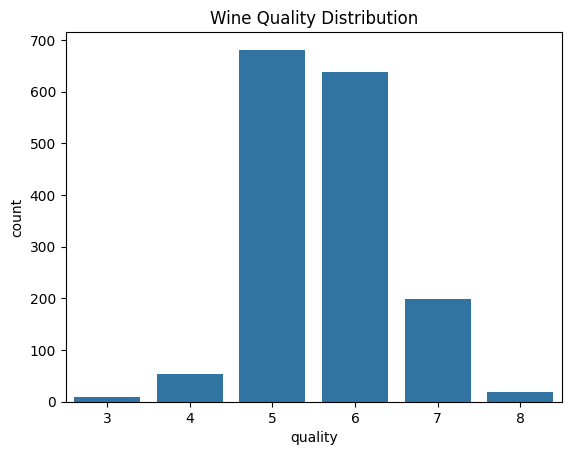

In [17]:

print(df.shape)
print(df.info())
print(df['quality'].value_counts())

# Class distribution
sns.countplot(x='quality', data=df)
plt.title("Wine Quality Distribution")
plt.show()

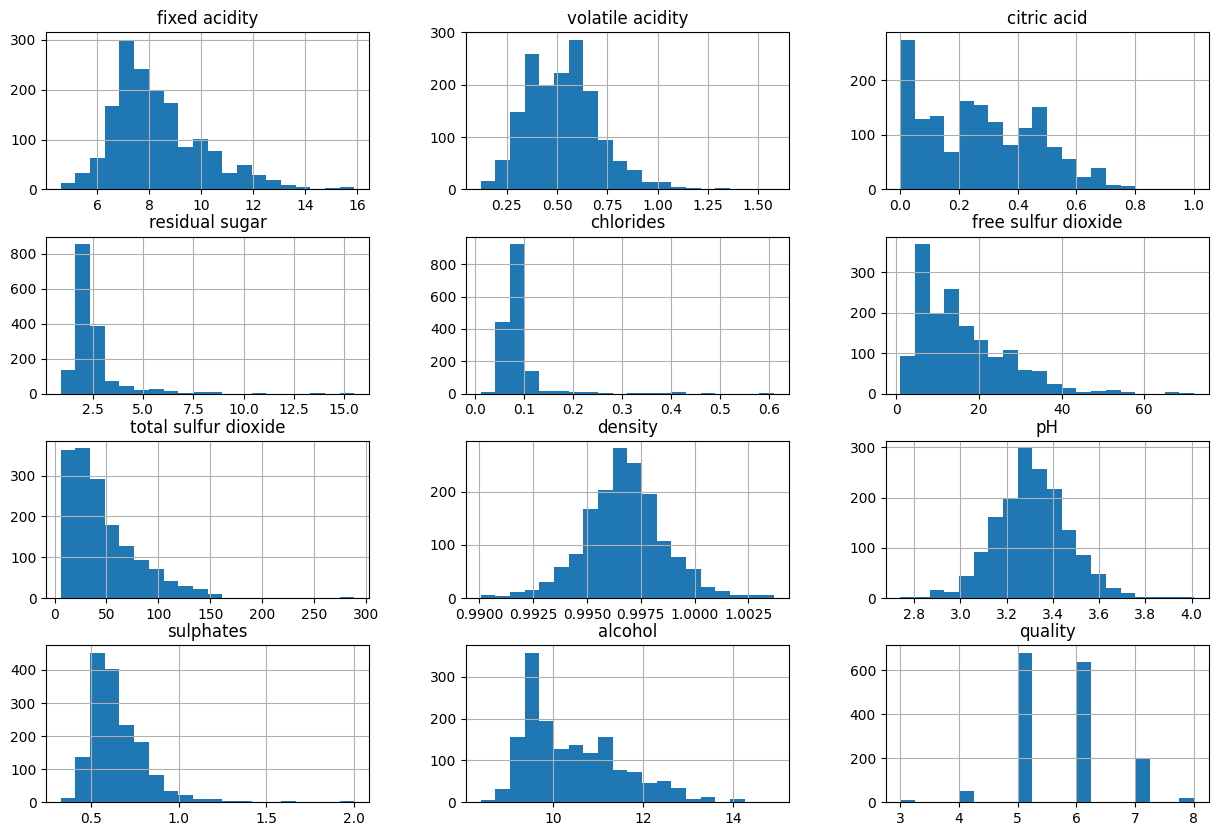

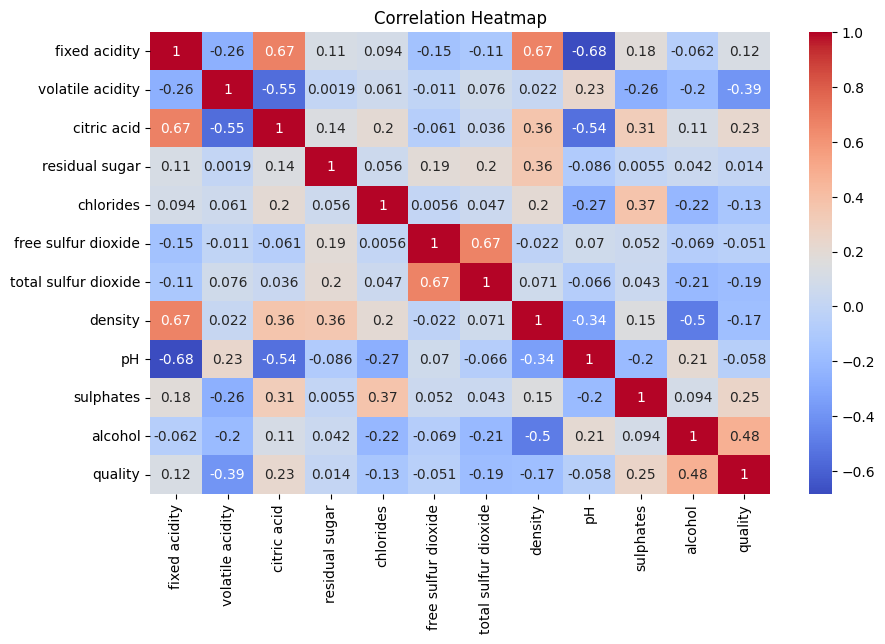

In [18]:
# 2. EDA
df.hist(bins=20, figsize=(15,10))
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [19]:
# 3. Feature Engineering (Binary classification: good vs bad)
df['quality_label'] = df['quality'].apply(lambda x: 1 if x>=7 else 0)

# Alternative: 3-class grouping
def quality_group(x):
    if x <= 4: return "low"
    elif x <= 6: return "medium"
    else: return "high"

df['quality_group'] = df['quality'].apply(quality_group)


In [20]:
# 4. Train/Test Split with Stratification
from sklearn.model_selection import train_test_split

X = df.drop(['quality','quality_label','quality_group'], axis=1)
y = df['quality_label']   # choose binary or 3-class

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [27]:
# 5. Train Classifiers
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC

sgd = SGDClassifier(random_state=42)
sgd.fit(X_train_scaled, y_train)

svc = SVC()
svc.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [28]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("----- Random Forest -----")
rf_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred, zero_division=0))
print(confusion_matrix(y_test, rf_pred))


print("\n----- SGD -----")
sgd_pred = sgd.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, sgd_pred))
print(classification_report(y_test, sgd_pred, zero_division=0))
print(confusion_matrix(y_test, sgd_pred))


print("\n----- SVC -----")
svc_pred = svc.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, svc_pred))
print(classification_report(y_test, svc_pred, zero_division=0))
print(confusion_matrix(y_test, svc_pred))

----- Random Forest -----
Accuracy: 0.94375
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       277
           1       0.93      0.63      0.75        43

    accuracy                           0.94       320
   macro avg       0.94      0.81      0.86       320
weighted avg       0.94      0.94      0.94       320

[[275   2]
 [ 16  27]]

----- SGD -----
Accuracy: 0.86875
              precision    recall  f1-score   support

           0       0.92      0.93      0.92       277
           1       0.51      0.47      0.49        43

    accuracy                           0.87       320
   macro avg       0.72      0.70      0.71       320
weighted avg       0.86      0.87      0.87       320

[[258  19]
 [ 23  20]]

----- SVC -----
Accuracy: 0.9
              precision    recall  f1-score   support

           0       0.91      0.98      0.94       277
           1       0.76      0.37      0.50        43

    accuracy              

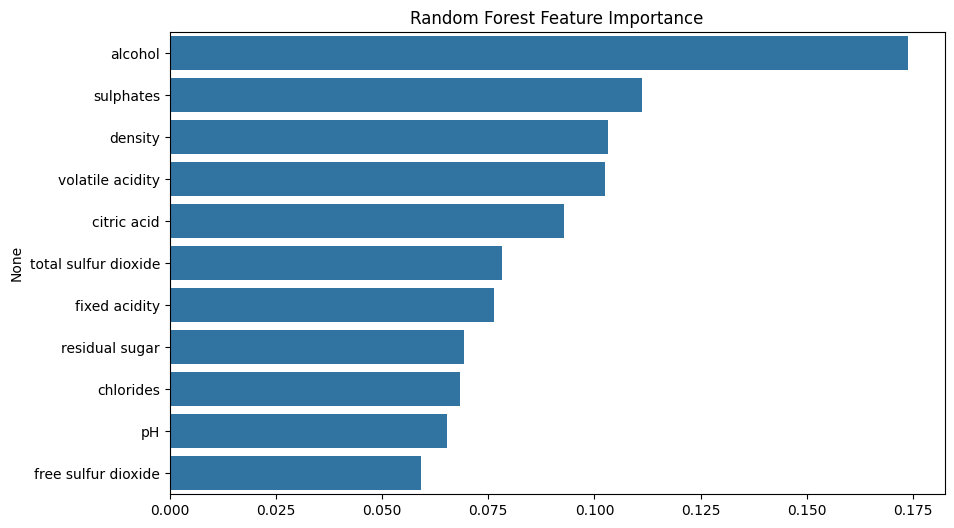

In [23]:
# 7. Feature Importance (Random Forest)
import numpy as np

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
sns.barplot(x=importances[indices], y=X.columns[indices])
plt.title("Random Forest Feature Importance")
plt.show()


In [24]:
# 8. Comparison Table
results = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append([name, acc])

pd.DataFrame(results, columns=['Model','Accuracy'])


,Model,Accuracy
0,Random Forest,0.943750
1,SGD,0.675000
2,SVC,0.865625
